# nitid D-FINE Tutorial

This notebook walks through the basic nitid workflow:

1. Set up the project environment
2. Download and wrap an official D-FINE checkpoint
3. Run prediction on a real image
4. Inspect and save results
5. Export the model
6. See how fine-tuning would be launched

This notebook is written to run locally from the nitid repository. Comments are included for the small changes needed when running it later in Google Colab.

## 0. Local vs Colab setup

**Local use today:** run this notebook from the repository root after installing the project dependencies.

**Future Colab use:** once the repository is public and the package/release flow is settled, replace the local setup cell with a clone/install cell, for example:

```python
# Colab-only example for the future
!git clone https://github.com/Vaelsys/nitid.git
%cd nitid
!pip install -e .
```

For now, this notebook uses the local checkout so we can test the unreleased code before it is merged.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if all((candidate / p).exists() for p in ["dfine", "tools", "configs"]):
            return candidate
    raise RuntimeError(
        "Could not find the nitid repository root. "
        "Run this notebook from the cloned nitid repo, or `cd` into it first."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)

print(f"Running in Colab: {IN_COLAB}")
print(f"Repository root: {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")

Running in Colab: False
Repository root: /Users/shihab/Documents/CODING/Internship/nitid-project
Working directory: /Users/shihab/Documents/CODING/Internship/nitid-project


## 1. Check the package imports

The public API is one entry point: import `NITID`, load a checkpoint, then call `predict()`, `train()`, `val()`, or `export()`.

In [2]:
from nitid import NITID

print("Imported NITID successfully")

Imported NITID successfully


## 2. Download and wrap a checkpoint

nitid needs a **wrapped** checkpoint. A wrapped checkpoint stores the model weights, D-FINE config, and class names together in one `.pth` file.

The command below downloads the official D-FINE-S COCO checkpoint and converts it into:

```text
models/dfine_s_wrapped.pth
```

You can replace `dfine_s` with `dfine_m`, `dfine_l`, or `dfine_x`.

In [ ]:
from dfine.utils.downloads import download_model

models_dir = REPO_ROOT / "models"
models_dir.mkdir(exist_ok=True)

checkpoint = download_model("dfine_s", output=models_dir)
print(f"Checkpoint ready: {checkpoint}")
print(f"Size: {checkpoint.stat().st_size / 1e6:.1f} MB")

/Users/shihab/Documents/CODING/Internship/nitid-project/models/dfine_s_wrapped.pth already exists. Use force=true to overwrite.
Checkpoint ready: /Users/shihab/Documents/CODING/Internship/nitid-project/models/dfine_s_wrapped.pth
Size: 41.9 MB


## 3. Download a test image

The image is downloaded at runtime so the repository does not need to store example image files.

In [4]:
from urllib.request import urlretrieve

outputs_dir = REPO_ROOT / "outputs"
outputs_dir.mkdir(exist_ok=True)

image_url = "https://ultralytics.com/images/bus.jpg"
image_path = outputs_dir / "bus.jpg"

if not image_path.exists():
    print(f"Downloading {image_url}")
    urlretrieve(image_url, image_path)

print(f"Image ready: {image_path}")

Image ready: /Users/shihab/Documents/CODING/Internship/nitid-project/outputs/bus.jpg


## 4. Run prediction with Python

This is the main user-facing workflow.

In [5]:
model = NITID(str(checkpoint), device="cpu", verbose=False)
results = model.predict(str(image_path), conf=0.5, verbose=False)

result = results[0]
detections = result.to_json()
print(result)
print("Detections:", len(result))
print(detections)

Results(path='/Users/shihab/Documents/CODING/Internship/nitid-project/outputs/bus.jpg', detections=6)
Detections: 6
[{'box': {'x1': 18.1181640625, 'y1': 231.2908477783203, 'x2': 804.4349975585938, 'y2': 729.9759521484375}, 'confidence': 0.943, 'class': 5, 'name': 'bus'}, {'box': {'x1': 48.869232177734375, 'y1': 400.42633056640625, 'x2': 246.90065002441406, 'y2': 905.1228637695312}, 'confidence': 0.9388, 'class': 0, 'name': 'person'}, {'box': {'x1': 667.76953125, 'y1': 394.85504150390625, 'x2': 809.8445434570312, 'y2': 883.6370849609375}, 'confidence': 0.9264, 'class': 0, 'name': 'person'}, {'box': {'x1': 224.0955810546875, 'y1': 405.5401611328125, 'x2': 344.00933837890625, 'y2': 860.8081665039062}, 'confidence': 0.9242, 'class': 0, 'name': 'person'}, {'box': {'x1': 0.067615807056427, 'y1': 552.8614501953125, 'x2': 63.94025802612305, 'y2': 874.0757446289062}, 'confidence': 0.8112, 'class': 0, 'name': 'person'}, {'box': {'x1': 0.0, 'y1': 253.34564208984375, 'x2': 33.58632278442383, 'y2':

## 5. Save and view the annotated image

`Results.save()` writes an annotated image with boxes and labels.

Saved annotated image to: /Users/shihab/Documents/CODING/Internship/nitid-project/outputs/bus_result.jpg


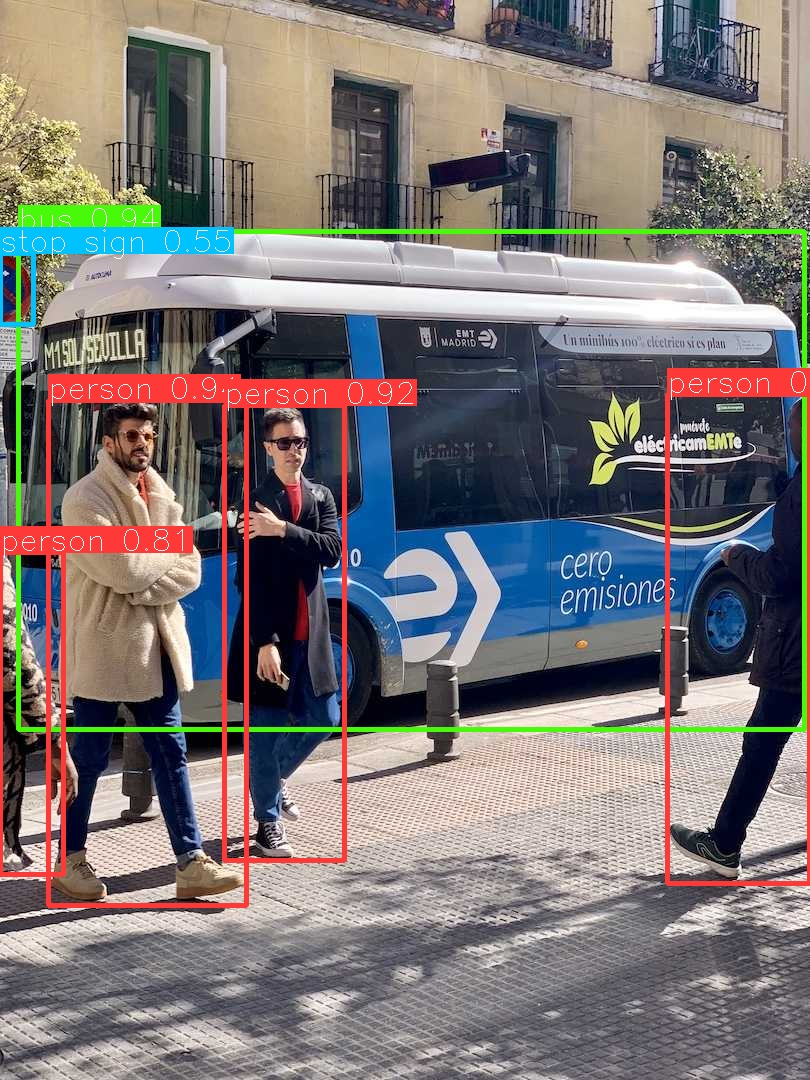

In [6]:
try:
    from IPython.display import Image, display
except ImportError:
    Image = None
    display = None

annotated_path = outputs_dir / "bus_result.jpg"
result.save(str(annotated_path))
print(f"Saved annotated image to: {annotated_path}")

if Image is not None and display is not None:
    display(Image(filename=str(annotated_path)))
else:
    print("Install IPython or open the saved file to view the annotated image.")

## 6. Run prediction with the CLI

The same checkpoint can be used from the command line.

Inside a notebook, we call the CLI with the current Python interpreter instead of `uv run`. This avoids environment mismatches when Jupyter is using a Conda or local kernel.

The equivalent terminal command is:

```bash
uv run nitid predict model=models/dfine_s_wrapped.pth source=outputs/bus.jpg conf=0.5
```


In [7]:
cmd = [
    sys.executable,
    "-m",
    "tools.dfine_cli",
    "predict",
    f"model={checkpoint}",
    f"source={image_path}",
    "conf=0.5",
]
print("Running:", " ".join(map(str, cmd)))
completed = subprocess.run(
    [str(x) for x in cmd],
    text=True,
    capture_output=True,
)

if completed.stdout:
    print(completed.stdout)
if completed.stderr:
    print(completed.stderr)

if completed.returncode != 0:
    raise RuntimeError(f"CLI prediction failed with exit code {completed.returncode}")

Running: /opt/homebrew/Caskroom/miniforge/base/envs/dfine/bin/python -m tools.dfine_cli predict model=/Users/shihab/Documents/CODING/Internship/nitid-project/models/dfine_s_wrapped.pth source=/Users/shihab/Documents/CODING/Internship/nitid-project/outputs/bus.jpg conf=0.5
[D-FINE] Loaded '/Users/shihab/Documents/CODING/Internship/nitid-project/models/dfine_s_wrapped.pth' — 10.3M params on cpu
Results(path='/Users/shihab/Documents/CODING/Internship/nitid-project/outputs/bus.jpg', detections=6)



## 7. Export the model

For a quick local smoke test, this notebook exports to TorchScript. ONNX export is also supported, but can take longer and requires ONNX dependencies.

The exporter writes to the current working directory, so this cell temporarily switches into `outputs/` before exporting.

In [8]:
original_cwd = Path.cwd()
os.chdir(outputs_dir)
try:
    exported = model.export(format="torchscript", imgsz=640, verbose=False)
finally:
    os.chdir(original_cwd)

exported_path = outputs_dir / exported.name
print(f"Exported model: {exported_path}")
print(f"Size: {exported_path.stat().st_size / 1e6:.1f} MB")

## 8. Fine-tuning workflow

Fine-tuning requires a COCO-format dataset and the `train` extra.

Local install:

```bash
uv sync --extra train
```

Future Colab install:

```python
!pip install -e ".[train]"
```

A real fine-tuning command looks like this:

```python
model.train(
    data="configs/datasets/example_custom.yml",
    epochs=10,
    batch=4,
    device="cuda",
)
```

This notebook does **not** run training by default because CPU training is slow and a real dataset path is required. Set `RUN_TRAINING = True` only after updating `DATA_YAML` to point at your dataset.

In [9]:
RUN_TRAINING = False
DATA_YAML = "configs/datasets/example_custom.yml"

if RUN_TRAINING:
    metrics = model.train(
        data=DATA_YAML,
        epochs=1,
        batch=2,
        device="cpu",
        verbose=True,
    )
    print(metrics)
else:
    print("Skipping training. Set RUN_TRAINING=True and DATA_YAML to a real dataset to run it.")

Skipping training. Set RUN_TRAINING=True and DATA_YAML to a real dataset to run it.


## 9. What files were created?

Generated files are intentionally written to ignored folders:

```text
models/   # downloaded wrapped checkpoints
outputs/  # images and exported models
```

These should stay local and should not be committed to Git.

In [10]:
for path in [checkpoint, image_path, annotated_path, exported_path]:
    print(path, f"{path.stat().st_size / 1e6:.1f} MB")

/Users/shihab/Documents/CODING/Internship/nitid-project/models/dfine_s_wrapped.pth 41.9 MB
/Users/shihab/Documents/CODING/Internship/nitid-project/outputs/bus.jpg 0.1 MB
/Users/shihab/Documents/CODING/Internship/nitid-project/outputs/bus_result.jpg 0.4 MB
/Users/shihab/Documents/CODING/Internship/nitid-project/outputs/dfine_640.torchscript 42.7 MB
